In [1]:
# 랜덤성 제어를 위한 표준 라이브러리 모듈을 불러옵니다.
import random
from collections import deque
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler


# 데이터셋을 불러옵니다.
dat = pd.read_csv(Path("../../data/processed/data_selected.csv"), index_col=0)

# 재현 가능한 실험을 위해 시드 값을 고정합니다.
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 CUDA를, 없으면 CPU를 사용하도록 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DDQN에서 사용할 Q-Network 구조를 정의합니다.
# 데이터 수가 많지 않으므로 과적합 가능성을 염두에 두고 2개 은닉층을 사용합니다.
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 96),
            nn.ReLU(),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.net(x)                         # (batch, 2)

# 경험을 저장하고 무작위 샘플링하기 위한 리플레이 버퍼를 정의합니다.
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(states).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones.astype(np.float32)).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)


# DDQN 에이전트를 정의합니다.
class DDQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.95,
        lr=5e-4,
        batch_size=64,
        memory_size=100_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        self.online_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(memory_size)
        self.total_steps = 0

    def act(self, state, epsilon: float = None):
        if epsilon is None:
            epsilon = self.epsilon

        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        #online_net에서 현재 Q값 계산
        q_values = self.online_net(states).gather(1, actions)
        #online_net에서 다음 행동 선택 
        next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
        #target_net에서 다음 행동의 Q값 계산
        next_q_values = self.target_net(next_states).gather(1, next_actions)
        target_q = rewards + (1 - dones) * self.gamma * next_q_values
        loss = F.mse_loss(q_values, target_q.detach())
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()
        self.total_steps += 1
        if self.total_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())
        return float(loss.item())

def encode_risk_labels(series):
    s = series.copy()
    # 문자열 타입이면 'High Risk' → 1, 'Low Risk' → 0 매핑
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s = s.map({'Low Risk': 0, 'High Risk': 1})
        if s.isna().any():
            raise ValueError(f"알 수 없는 라벨 값이 있습니다: {series[s.isna()].unique()}")
    # 숫자형이면 그냥 int 변환
    return s.fillna(0).astype(int).to_numpy()

# ---- 데이터 준비 (Train/Valid/Test Split 먼저, 그 후 Scaling) ----

risk_label_col = "Risk_Label"
feature_cols = [c for c in dat.select_dtypes(include=[np.number]).columns if c != risk_label_col]
if len(feature_cols) == 0:
    raise ValueError("학습에 사용할 수치형 feature가 없습니다.")

risk_label_data = encode_risk_labels(dat[risk_label_col])
feature_data_raw = dat[feature_cols].fillna(0.0).to_numpy()
n_steps = len(dat)

train_end = int(n_steps * 0.45)
valid_end = int(n_steps * 0.80)
test_ratio = 1 - (valid_end / n_steps)

train_indices = np.arange(0, train_end)
valid_indices = np.arange(train_end, valid_end)
test_indices  = np.arange(valid_end, n_steps)

train_feature_raw = feature_data_raw[train_indices]
train_label = risk_label_data[train_indices]

valid_feature_raw = feature_data_raw[valid_indices]
valid_label = risk_label_data[valid_indices]
if len(valid_label) < 2:
    raise ValueError("Validation set 길이가 너무 짧아 tuning/selection 분할이 불가능합니다. split 비율을 조정하세요.")
valid_split_point = int(len(valid_label) * 0.65)
valid_tune_feature_raw = valid_feature_raw[:valid_split_point]
valid_tune_label = valid_label[:valid_split_point]
valid_select_feature_raw = valid_feature_raw[valid_split_point:]
valid_select_label = valid_label[valid_split_point:]

test_feature_raw = feature_data_raw[test_indices]
test_label = risk_label_data[test_indices]

def summarize_class_ratio(name, y):
    n_total = len(y)
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    r0 = n0 / n_total if n_total > 0 else 0.0
    r1 = n1 / n_total if n_total > 0 else 0.0
    imbalance = (n1 / max(n0, 1)) if n_total > 0 else 0.0
    print(f"{name:>5} | n={n_total:4d} | class0={n0:4d} ({r0:.2%}) | class1={n1:4d} ({r1:.2%}) | c1/c0={imbalance:.4f})")
    if n0 == 0 or n1 == 0:
        raise ValueError(f"{name} set에 클래스 0 또는 1이 없습니다. split 비율 또는 기간을 조정하세요.")

print("Class Ratio Summary (Before ADASYN)")
summarize_class_ratio("Train", train_label)
summarize_class_ratio("ValTun", valid_tune_label)
summarize_class_ratio("ValSel", valid_select_label)
summarize_class_ratio("Test", test_label)

# 보상 계산에 사용할 class_ratio는 원본 train 기준으로 고정합니다.
n_negative_original = (train_label == 0).sum()
n_positive_original = (train_label == 1).sum()
class_ratio_reward = n_positive_original / max(n_negative_original, 1)
print(f"Reward class ratio (original train): {class_ratio_reward:.4f}")

# ---- ADASYN을 적용하지 않고 원본 학습 데이터를 그대로 사용 ----
train_feature = train_feature_raw.astype(np.float32)
train_label = train_label.astype(np.int64)

scaler = MinMaxScaler()
scaler.fit(train_feature)

train_feature = scaler.transform(train_feature).astype(np.float32)
valid_tune_feature = scaler.transform(valid_tune_feature_raw).astype(np.float32)
valid_select_feature = scaler.transform(valid_select_feature_raw).astype(np.float32)
test_feature = scaler.transform(test_feature_raw).astype(np.float32)

print("=" * 60)
print("Data Split Information")
print("=" * 60)
print(f"Total samples: {n_steps}")
print(f"Train set: {len(train_label)} samples")
print(f"  - Class 0: {(train_label==0).sum()}, Class 1: {(train_label==1).sum()}")
print(f"Valid(Tune) set: {len(valid_tune_label)} samples")
print(f"  - Class 0: {(valid_tune_label==0).sum()}, Class 1: {(valid_tune_label==1).sum()}")
print(f"Valid(Select) set: {len(valid_select_label)} samples")
print(f"  - Class 0: {(valid_select_label==0).sum()}, Class 1: {(valid_select_label==1).sum()}")
print(f"Test set: {len(test_indices)} samples ({test_ratio*100:.1f}%)")
print(f"  - Class 0: {(test_label==0).sum()}, Class 1: {(test_label==1).sum()}")

# 원본 학습 세트의 클래스 비율을 그대로 사용합니다.
n_negative = (train_label == 0).sum()
n_positive = (train_label == 1).sum()
class_ratio = class_ratio_reward

print(f"\nClass ratio (train set): {n_positive / max(n_negative, 1):.4f}")
print(f"Class ratio used for reward: {class_ratio:.4f}")
print("=" * 60)

state_dim = len(feature_cols)
action_dim = 2

# ---- DDQN reward / sampling 설정 ----
# final2 계열의 안정적인 보상 체계를 사용합니다.
# 목표: FP는 소폭 억제하되, FN이 크게 늘지 않도록 FN 벌점은 강하게 유지합니다.
HIGH_RISK_PROB = 0.65

def compute_reward(action, actual_label, class_ratio=None):
    action = int(action)
    actual_label = int(actual_label)

    # action: 0 = Low risk 예측, 1 = High risk 예측
    # actual_label: 0 = 실제 Low risk, 1 = 실제 High risk
    if actual_label == 0 and action == 0:
        return 0.4      # TN
    elif actual_label == 0 and action == 1:
        return -0.9     # FP: final2보다 소폭 강화
    elif actual_label == 1 and action == 1:
        return 4.0      # TP
    elif actual_label == 1 and action == 0:
        return -6.0     # FN: 완화하지 않음

# train_label에서 High Risk 인덱스를 미리 계산
high_risk_indices = np.where(train_label == 1)[0]
print(f"High Risk 인덱스 수 (train): {len(high_risk_indices)}")

def get_balanced_start_idx(max_steps, high_risk_prob=HIGH_RISK_PROB):
    """
    high_risk_prob 확률로 High Risk가 윈도우 안에
    반드시 포함되는 start_idx를 반환.
    
    나머지 확률로는 기존 랜덤 방식 사용.
    시계열 순서는 항상 유지됨.
    
    Parameters:
        max_steps: 에피소드 길이 (500)
        high_risk_prob: High Risk 포함 윈도우 선택 확률
    
    Returns:
        start_idx: 에피소드 시작 인덱스
    """
    n = len(train_feature)
    max_start = n - max_steps - 1
    if max_start < 0:
        raise ValueError("max_steps가 train_feature 길이에 비해 너무 큽니다.")
    
    if np.random.random() < high_risk_prob and len(high_risk_indices) > 0:
        # High Risk 인덱스 중 하나를 무작위 선택
        hr_idx = np.random.choice(high_risk_indices)
        
        # 이 hr_idx가 윈도우 안에 포함되는
        # start_idx의 유효 범위 계산:
        # 조건: start_idx <= hr_idx <= start_idx + max_steps - 1
        # → low = hr_idx - max_steps + 1
        # → high = hr_idx
        low  = max(0, hr_idx - max_steps + 1)
        high = min(max_start, hr_idx)
        
        if low > high:
            # 유효 범위가 없으면 (데이터 끝부분 등) 랜덤
            return np.random.randint(0, max_start + 1)
        
        # 유효 범위 안에서 랜덤 선택
        # → High Risk가 윈도우 앞/중간/뒤 어디든 포함됨
        return int(np.random.randint(low, high + 1))
    
    else:
        # 기존 방식: 완전 랜덤
        return int(np.random.randint(0, max_start + 1))

Class Ratio Summary (Before ADASYN)
Train | n=1848 | class0=1638 (88.64%) | class1= 210 (11.36%) | c1/c0=0.1282)
ValTun | n= 934 | class0= 829 (88.76%) | class1= 105 (11.24%) | c1/c0=0.1267)
ValSel | n= 504 | class0= 427 (84.72%) | class1=  77 (15.28%) | c1/c0=0.1803)
 Test | n= 822 | class0= 723 (87.96%) | class1=  99 (12.04%) | c1/c0=0.1369)
Reward class ratio (original train): 0.1282
Data Split Information
Total samples: 4108
Train set: 1848 samples
  - Class 0: 1638, Class 1: 210
Valid(Tune) set: 934 samples
  - Class 0: 829, Class 1: 105
Valid(Select) set: 504 samples
  - Class 0: 427, Class 1: 77
Test set: 822 samples (20.0%)
  - Class 0: 723, Class 1: 99

Class ratio (train set): 0.1282
Class ratio used for reward: 0.1282
High Risk 인덱스 수 (train): 210



HYPERPARAMETER GRID SEARCH WITH TARGETED Q-MARGIN THRESHOLD (Total: 48 combinations)
Target Test CM: TN≈620, FP≈100, FN≈30, TP≈70

[1/48] gamma=0.00, lr=1e-04, eps_decay=0.990, bs=32
  Ep  20 | Tune H1: 0.4290 G-mean: 0.6370 F1: 0.3234 (Sens: 0.5143, Spec: 0.7889, Pre: 0.2358, Pred1: 0.2452, FP: 175, FN: 51, TP: 54) | Tloss: 3.5794 | Th: 0.341627
  Ep  40 | Tune H1: 0.4305 G-mean: 0.6514 F1: 0.3215 (Sens: 0.5619, Spec: 0.7551, Pre: 0.2252, Pred1: 0.2805, FP: 203, FN: 46, TP: 59) | Tloss: 3.9499 | Th: 0.287247
  Ep  60 | Tune H1: 0.4334 G-mean: 0.6505 F1: 0.3249 (Sens: 0.5524, Spec: 0.7660, Pre: 0.2302, Pred1: 0.2698, FP: 194, FN: 47, TP: 58) | Tloss: 3.6258 | Th: 0.380776
  Ep  80 | Tune H1: 0.4397 G-mean: 0.6566 F1: 0.3305 (Sens: 0.5619, Spec: 0.7672, Pre: 0.2341, Pred1: 0.2698, FP: 193, FN: 46, TP: 59) | Tloss: 3.4047 | Th: 0.180791
  Ep 100 | Tune H1: 0.4371 G-mean: 0.6525 F1: 0.3286 (Sens: 0.5524, Spec: 0.7708, Pre: 0.2339, Pred1: 0.2655, FP: 190, FN: 47, TP: 58) | Tloss: 3.4245 |

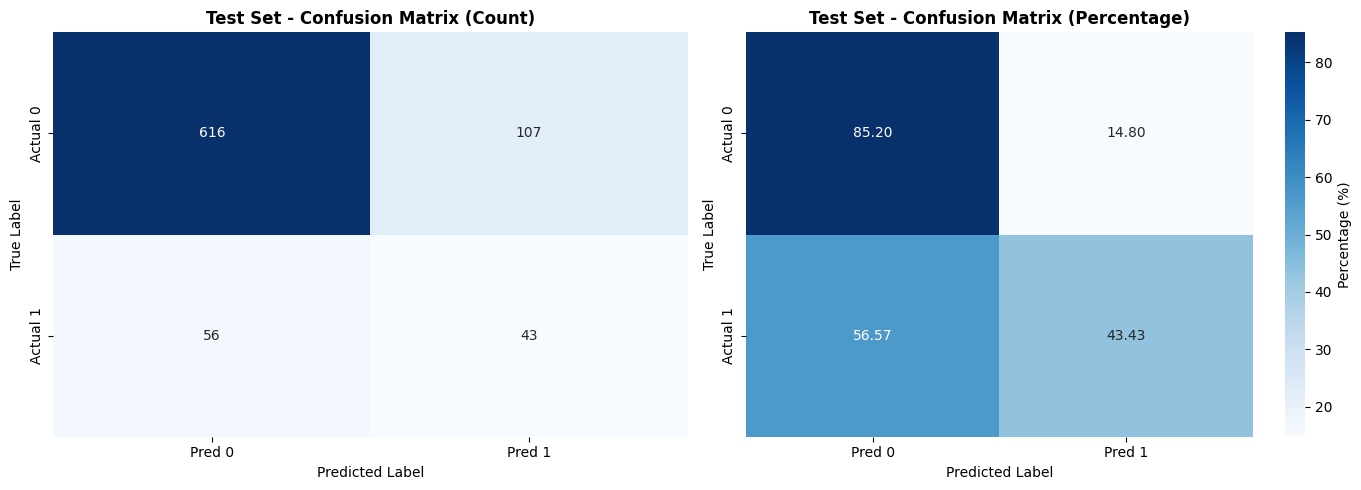


상세 메트릭 (Test Set):
Sensitivity (Recall for Class 1): 0.4343
Specificity (Recall for Class 0): 0.8520
Precision (Class 1):              0.2867
Predicted High Ratio:             0.1825
F1-Score:                         0.3454
G-mean:                           0.6083
H1 (G-mean & F1):                 0.4406

VALIDATION SET vs TEST SET 성능 비교

Validation(Selection) Set - H1: 0.4803
Test Set - H1:                  0.4406
Difference (Valid - Test):      0.0397

Validation Confusion Matrix:
[[336  91]
 [ 37  40]]

Test Confusion Matrix:
[[616 107]
 [ 56  43]]


In [2]:
# ---- Validation 기반 하이퍼파라미터 Grid Search + Q-margin threshold ----
# 목표 confusion matrix(Test 기준): TN≈620, FP≈100, FN≈30, TP≈70
# 핵심: 보상함수를 크게 흔들지 않고, Q-margin threshold 선택을 목표 trade-off에 맞춥니다.
from itertools import product

param_grid = {
    "gamma": [0.0, 0.5, 0.9, 0.95],
    "lr": [1e-4, 5e-4, 1e-3],
    "epsilon_decay": [0.99, 0.995],
    "batch_size": [32, 64],
}

# ------------------------------------------------------------------
# Target-aware Q-margin threshold 설정
# ------------------------------------------------------------------
# Test 기준 목표:
#   TN≈620, FP≈100, FN≈30, TP≈70
# Test 실제 분포가 대략 class0=723, class1=99이므로 목표 비율은 다음과 같습니다.
TARGET_TP_RATE = 70 / 99          # sensitivity target ≈ 0.707
TARGET_SPECIFICITY = 620 / 723    # specificity target ≈ 0.858
TARGET_PRECISION = 70 / (70 + 100)
TARGET_PRED_HIGH_RATIO = (70 + 100) / 822

# 후보 필터. 너무 빡세면 fallback에서 완화됩니다.
H1_TOLERANCE = 0.90
MIN_SENSITIVITY_ABS = 0.55
MIN_SPECIFICITY_ABS = 0.75
MIN_PRED_HIGH_RATIO = 0.16
MAX_PRED_HIGH_RATIO = 0.30


def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = int(tn + fp + fn + tp)
    actual_high = int(fn + tp)
    actual_low = int(tn + fp)
    pred_high = int(fp + tp)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    pred_high_ratio = pred_high / total if total > 0 else 0.0
    actual_high_ratio = actual_high / total if total > 0 else 0.0

    gmean = float(np.sqrt(sensitivity * specificity))
    f1 = float(2 * precision * sensitivity / (precision + sensitivity)) if (precision + sensitivity) > 0 else 0.0
    h1 = float(2 * gmean * f1 / (gmean + f1)) if (gmean + f1) > 0 else 0.0

    return {
        "gmean": gmean,
        "f1": f1,
        "h1": h1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "pred_high_ratio": pred_high_ratio,
        "actual_high_ratio": actual_high_ratio,
        "pred_high": pred_high,
        "actual_high": actual_high,
        "actual_low": actual_low,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "cm": cm,
    }


def add_target_scores(row, actual_low, actual_high, total):
    """
    validation set 크기에 맞춰 test 목표 confusion matrix의 비율을 이식합니다.
    예: validation actual_high가 77이면 목표 TP는 77 * 70/99 정도로 계산합니다.
    """
    target_tp = TARGET_TP_RATE * actual_high
    target_fn = actual_high - target_tp
    target_tn = TARGET_SPECIFICITY * actual_low
    target_fp = actual_low - target_tn
    target_pred_high = target_tp + target_fp
    target_pred_high_ratio = target_pred_high / total if total > 0 else TARGET_PRED_HIGH_RATIO

    # count loss: validation 크기에 맞춘 목표 TP/FP에 가까운지
    tp_gap = (row["tp"] - target_tp) / max(actual_high, 1)
    fp_gap = (row["fp"] - target_fp) / max(actual_low, 1)

    # rate loss: 목표 민감도/특이도/정밀도/Pred1 비율에 가까운지
    sens_gap = (row["sensitivity"] - TARGET_TP_RATE) / 0.15
    spec_gap = (row["specificity"] - TARGET_SPECIFICITY) / 0.10
    prec_gap = (row["precision"] - TARGET_PRECISION) / 0.15
    pred_gap = (row["pred_high_ratio"] - TARGET_PRED_HIGH_RATIO) / 0.07

    target_loss = (
        1.30 * sens_gap ** 2 +
        1.00 * spec_gap ** 2 +
        0.80 * pred_gap ** 2 +
        0.50 * prec_gap ** 2 +
        0.80 * tp_gap ** 2 +
        0.60 * fp_gap ** 2
    )

    row["target_tp"] = target_tp
    row["target_fp"] = target_fp
    row["target_tn"] = target_tn
    row["target_fn"] = target_fn
    row["target_pred_high_ratio"] = target_pred_high_ratio
    row["tp_gap"] = row["tp"] - target_tp
    row["fp_gap"] = row["fp"] - target_fp
    row["target_loss"] = float(target_loss)
    # loss가 낮고 H1이 높은 후보를 우선. target_loss가 주 기준입니다.
    row["target_score"] = float(-target_loss + 0.20 * row["h1"])
    return row


def predict_q_values(model, features):
    model.eval()
    q_list = []
    with torch.no_grad():
        for t in range(len(features)):
            state_t = torch.FloatTensor(features[t]).unsqueeze(0).to(device)
            q_values = model(state_t).detach().cpu().numpy()[0]
            q_list.append(q_values)
    return np.asarray(q_list)


def get_q_margin(model, features):
    q_values = predict_q_values(model, features)
    margins = q_values[:, 1] - q_values[:, 0]
    return margins, q_values


def predict_labels_qmargin(model, features, threshold=0.0):
    margins, _ = get_q_margin(model, features)
    return (margins >= threshold).astype(int)


def predict_labels_argmax(model, features):
    preds = []
    with torch.no_grad():
        for t in range(len(features)):
            state_t = torch.FloatTensor(features[t]).unsqueeze(0).to(device)
            q_values = model(state_t)
            preds.append(int(torch.argmax(q_values, dim=1).item()))
    return np.array(preds)


def evaluate_qmargin(model, x_valid, y_valid, threshold):
    preds = predict_labels_qmargin(model, x_valid, threshold=threshold)
    m = compute_metrics(y_valid, preds)
    total = len(y_valid)
    actual_high = int(np.sum(y_valid == 1))
    actual_low = total - actual_high
    row = {k: v for k, v in m.items() if k != "cm"}
    row = add_target_scores(row, actual_low=actual_low, actual_high=actual_high, total=total)
    m.update({k: v for k, v in row.items() if k not in m})
    return m


def make_threshold_candidates(margins):
    margins = np.asarray(margins, dtype=float)
    finite_margins = margins[np.isfinite(margins)]
    if len(finite_margins) == 0:
        return np.array([0.0])

    # 분위수 기반 후보를 촘촘히 둡니다.
    qs = np.linspace(0.005, 0.995, 199)
    candidates = np.quantile(finite_margins, qs)
    candidates = np.concatenate([
        candidates,
        np.array([0.0, finite_margins.min() - 1e-6, finite_margins.max() + 1e-6])
    ])
    return np.unique(np.round(candidates, 10))


def select_qmargin_threshold(model, x_valid, y_valid,
                             h1_tolerance=H1_TOLERANCE,
                             min_sensitivity_abs=MIN_SENSITIVITY_ABS,
                             min_specificity_abs=MIN_SPECIFICITY_ABS,
                             min_pred_high_ratio=MIN_PRED_HIGH_RATIO,
                             max_pred_high_ratio=MAX_PRED_HIGH_RATIO):
    """
    validation에서 목표 confusion matrix에 가까운 Q-margin threshold를 선택합니다.

    목표 방향:
    - FP를 final2의 65보다 늘리되, 약 100 수준에서 통제
    - TP를 27에서 70 근처로 회복
    - 즉 Pred 1 비율을 대략 0.20~0.25 부근으로 유도
    """
    margins, _ = get_q_margin(model, x_valid)
    thresholds = make_threshold_candidates(margins)

    total = len(y_valid)
    actual_high = int(np.sum(y_valid == 1))
    actual_low = total - actual_high

    rows = []
    for th in thresholds:
        preds = (margins >= th).astype(int)
        m = compute_metrics(y_valid, preds)
        row = {"threshold": float(th), **{k: v for k, v in m.items() if k != "cm"}}
        row = add_target_scores(row, actual_low=actual_low, actual_high=actual_high, total=total)
        rows.append(row)

    result_df = pd.DataFrame(rows)
    best_h1 = float(result_df["h1"].max())

    # 1차: 목표 trade-off 영역 안에서 선택
    candidates = result_df[
        (result_df["h1"] >= best_h1 * h1_tolerance) &
        (result_df["sensitivity"] >= min_sensitivity_abs) &
        (result_df["specificity"] >= min_specificity_abs) &
        (result_df["pred_high_ratio"] >= min_pred_high_ratio) &
        (result_df["pred_high_ratio"] <= max_pred_high_ratio)
    ].copy()

    # 2차 fallback: H1 제약을 완화
    if len(candidates) == 0:
        candidates = result_df[
            (result_df["sensitivity"] >= min_sensitivity_abs) &
            (result_df["specificity"] >= min_specificity_abs) &
            (result_df["pred_high_ratio"] >= min_pred_high_ratio) &
            (result_df["pred_high_ratio"] <= max_pred_high_ratio)
        ].copy()

    # 3차 fallback: pred_high 범위만 유지
    if len(candidates) == 0:
        candidates = result_df[
            (result_df["pred_high_ratio"] >= min_pred_high_ratio) &
            (result_df["pred_high_ratio"] <= max_pred_high_ratio)
        ].copy()

    # 4차 fallback: 전체 후보 중 목표 loss 최소
    if len(candidates) == 0:
        candidates = result_df.copy()

    # target_loss가 가장 낮은 후보를 우선 선택합니다.
    # 그 다음 H1, precision, sensitivity를 보조 기준으로 사용합니다.
    candidates = candidates.sort_values(
        by=["target_loss", "h1", "precision", "sensitivity", "specificity"],
        ascending=[True, False, False, False, False]
    ).reset_index(drop=True)

    selected = candidates.iloc[0].to_dict()
    selected_threshold = float(selected["threshold"])
    selected_metrics = evaluate_qmargin(model, x_valid, y_valid, selected_threshold)
    selected_metrics.update({
        "target_loss": float(selected["target_loss"]),
        "target_score": float(selected["target_score"]),
        "target_tp": float(selected["target_tp"]),
        "target_fp": float(selected["target_fp"]),
        "target_tn": float(selected["target_tn"]),
        "target_fn": float(selected["target_fn"]),
        "tp_gap": float(selected["tp_gap"]),
        "fp_gap": float(selected["fp_gap"]),
        "target_pred_high_ratio": float(selected["target_pred_high_ratio"]),
    })

    threshold_table = result_df.sort_values(
        by=["target_loss", "h1", "precision"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    return selected_threshold, selected_metrics, threshold_table


# ---- Grid Search ----
grid_search_results = []
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print("\n" + "=" * 80)
print(f"HYPERPARAMETER GRID SEARCH WITH TARGETED Q-MARGIN THRESHOLD (Total: {len(param_combinations)} combinations)")
print("Target Test CM: TN≈620, FP≈100, FN≈30, TP≈70")
print("=" * 80)

patience = 25
min_episodes = 60
best_overall_select_score = -np.inf
best_overall_params = None
best_overall_threshold = 0.0

for idx, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    gamma, lr, epsilon_decay, batch_size = params

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    print(f"\n[{idx+1}/{len(param_combinations)}] gamma={gamma:.2f}, lr={lr:.0e}, eps_decay={epsilon_decay:.3f}, bs={batch_size}")

    agent_tune = DDQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=gamma,
        lr=lr,
        batch_size=batch_size,
        memory_size=50_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=epsilon_decay,
    )

    episodes_tune = 200
    max_steps_tune = 500
    best_tune_score = -np.inf
    best_tune_h1 = -1.0
    best_tune_threshold = 0.0
    best_tune_state_dict = None
    patience_counter = 0

    for ep in range(1, episodes_tune + 1):
        start_idx = get_balanced_start_idx(max_steps_tune, high_risk_prob=HIGH_RISK_PROB)
        episode_reward = 0.0

        for i in range(max_steps_tune):
            state = train_feature[start_idx + i]
            next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
            actual_label = train_label[start_idx + i]

            action = agent_tune.act(state)
            reward = compute_reward(action, actual_label, class_ratio)
            done = i == (max_steps_tune - 1)

            agent_tune.memory.push(state, action, reward, next_state, done)
            _ = agent_tune.update()
            episode_reward += reward

        agent_tune.decay_epsilon()

        if ep % 5 == 0:
            agent_tune.online_net.eval()
            tune_threshold, tune_metrics, _ = select_qmargin_threshold(
                agent_tune.online_net, valid_tune_feature, valid_tune_label
            )
            agent_tune.online_net.train()

            tune_score = tune_metrics["target_score"]
            if tune_score > best_tune_score:
                best_tune_score = tune_score
                best_tune_h1 = tune_metrics["h1"]
                best_tune_threshold = tune_threshold
                patience_counter = 0
                best_tune_state_dict = {k: v.detach().cpu().clone() for k, v in agent_tune.online_net.state_dict().items()}
            else:
                patience_counter += 1

            if ep % 20 == 0:
                print(
                    f"  Ep {ep:3d} | Tune H1: {tune_metrics['h1']:.4f} "
                    f"G-mean: {tune_metrics['gmean']:.4f} F1: {tune_metrics['f1']:.4f} "
                    f"(Sens: {tune_metrics['sensitivity']:.4f}, Spec: {tune_metrics['specificity']:.4f}, "
                    f"Pre: {tune_metrics['precision']:.4f}, Pred1: {tune_metrics['pred_high_ratio']:.4f}, "
                    f"FP: {tune_metrics['fp']}, FN: {tune_metrics['fn']}, TP: {tune_metrics['tp']}) "
                    f"| Tloss: {tune_metrics['target_loss']:.4f} | Th: {tune_threshold:.6f}"
                )

            if ep > min_episodes and patience_counter >= patience:
                break

    agent_tune.online_net.eval()
    if best_tune_state_dict is not None:
        agent_tune.online_net.load_state_dict(best_tune_state_dict)

    select_metrics = evaluate_qmargin(
        agent_tune.online_net, valid_select_feature, valid_select_label, best_tune_threshold
    )

    grid_search_results.append({
        "params": param_dict,
        "best_tune_h1": best_tune_h1,
        "tune_threshold": best_tune_threshold,
        "select_score": select_metrics["target_score"],
        "select_target_loss": select_metrics["target_loss"],
        "select_h1": select_metrics["h1"],
        "select_gmean": select_metrics["gmean"],
        "select_f1": select_metrics["f1"],
        "select_sensitivity": select_metrics["sensitivity"],
        "select_specificity": select_metrics["specificity"],
        "select_precision": select_metrics["precision"],
        "select_pred_high_ratio": select_metrics["pred_high_ratio"],
        "select_fp": select_metrics["fp"],
        "select_fn": select_metrics["fn"],
        "select_tp": select_metrics["tp"],
        "select_tn": select_metrics["tn"],
    })

    if select_metrics["target_score"] > best_overall_select_score:
        best_overall_select_score = select_metrics["target_score"]
        best_overall_params = param_dict
        best_overall_threshold = best_tune_threshold

# target_loss 우선, H1 보조
important_results = sorted(grid_search_results, key=lambda x: (x["select_target_loss"], -x["select_h1"]))
grid_search_results = important_results

print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETERS - TARGET CM 기준")
print("=" * 80)
for i, result in enumerate(grid_search_results[:5]):
    print(
        f"{i+1}. Tloss: {result['select_target_loss']:.4f} | H1: {result['select_h1']:.4f} | "
        f"Sens: {result['select_sensitivity']:.4f} | Spec: {result['select_specificity']:.4f} | "
        f"Prec: {result['select_precision']:.4f} | Pred1: {result['select_pred_high_ratio']:.4f} | "
        f"TN={result['select_tn']}, FP={result['select_fp']}, FN={result['select_fn']}, TP={result['select_tp']} | "
        f"Th: {result['tune_threshold']:.6f} | Params: {result['params']}"
    )

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS")
print("=" * 80)
for k, v in best_overall_params.items():
    print(f"{k}: {v}")
print(f"Best Selection target score: {best_overall_select_score:.4f}")
print(f"Threshold selected during grid search: {best_overall_threshold:.6f}")
print("=" * 80)


# ---- 최적 파라미터로 본 학습 ----
print("\nTraining with best hyperparameters...")
agent = DDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gamma=best_overall_params["gamma"],
    lr=best_overall_params["lr"],
    batch_size=best_overall_params["batch_size"],
    memory_size=50_000,
    target_update=2000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=best_overall_params["epsilon_decay"],
)

episodes = 600
max_steps = 500
scores = []
valid_scores = []
best_ckpt_score = -np.inf
best_ckpt_valid_h1 = -1.0
best_ckpt_epoch = 0
best_ckpt_state_dict = None
best_ckpt_threshold = 0.0
best_ckpt_metrics = None
best_threshold_table = None

for ep in range(1, episodes + 1):
    episode_reward = 0.0
    start_idx = get_balanced_start_idx(max_steps, high_risk_prob=HIGH_RISK_PROB)

    for i in range(max_steps):
        state = train_feature[start_idx + i]
        next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
        actual_label = train_label[start_idx + i]

        action = agent.act(state)
        reward = compute_reward(action, actual_label, class_ratio)
        done = i == (max_steps - 1)

        agent.memory.push(state, action, reward, next_state, done)
        _ = agent.update()
        episode_reward += reward

    agent.decay_epsilon()
    scores.append(episode_reward)

    if ep % 10 == 0:
        agent.online_net.eval()
        valid_threshold, valid_metrics, threshold_table = select_qmargin_threshold(
            agent.online_net, valid_select_feature, valid_select_label
        )
        valid_scores.append(valid_metrics["target_score"])

        if valid_metrics["target_score"] > best_ckpt_score:
            best_ckpt_score = valid_metrics["target_score"]
            best_ckpt_valid_h1 = valid_metrics["h1"]
            best_ckpt_epoch = ep
            best_ckpt_threshold = valid_threshold
            best_ckpt_metrics = valid_metrics
            best_threshold_table = threshold_table
            best_ckpt_state_dict = {k: v.detach().cpu().clone() for k, v in agent.online_net.state_dict().items()}
        agent.online_net.train()

        print(
            f"Episode {ep:3d} | Reward: {np.mean(scores[-10:]):8.5f} | "
            f"Tloss: {valid_metrics['target_loss']:.4f} | H1: {valid_metrics['h1']:.4f} | "
            f"G-mean: {valid_metrics['gmean']:.4f} | F1: {valid_metrics['f1']:.4f} | "
            f"Sens: {valid_metrics['sensitivity']:.4f} | Spec: {valid_metrics['specificity']:.4f} | "
            f"Prec: {valid_metrics['precision']:.4f} | Pred1: {valid_metrics['pred_high_ratio']:.4f} | "
            f"TN={valid_metrics['tn']}, FP={valid_metrics['fp']}, FN={valid_metrics['fn']}, TP={valid_metrics['tp']} | "
            f"Th: {valid_threshold:.6f} | Best score: {best_ckpt_score:.4f}"
        )

print("최종 학습 완료")
if best_ckpt_state_dict is not None:
    agent.online_net.load_state_dict(best_ckpt_state_dict)
    agent.target_net.load_state_dict(best_ckpt_state_dict)
    print(
        f"Best checkpoint restored: epoch={best_ckpt_epoch}, "
        f"valid_h1={best_ckpt_valid_h1:.4f}, target_score={best_ckpt_score:.4f}, "
        f"threshold={best_ckpt_threshold:.6f}"
    )

agent.online_net.eval()

# ---- Test 평가: Q-margin threshold 적용 ----
test_q_margins, test_q_values = get_q_margin(agent.online_net, test_feature)
test_predictions = (test_q_margins >= best_ckpt_threshold).astype(int)

# 비교용 argmax 예측도 같이 계산
argmax_test_predictions = predict_labels_argmax(agent.online_net, test_feature)
argmax_metrics = compute_metrics(test_label, argmax_test_predictions)
qmargin_metrics = evaluate_qmargin(agent.online_net, test_feature, test_label, best_ckpt_threshold)

cm_test = qmargin_metrics["cm"]
tn, fp, fn, tp = cm_test.ravel()

print("\n" + "=" * 60)
print("TEST SET - DDQN + Targeted Q-margin threshold 최종 성능 평가")
print("Target CM: TN≈620, FP≈100, FN≈30, TP≈70")
print("=" * 60)
print(f"Selected Q-margin threshold: {best_ckpt_threshold:.6f}")
print(f"Q-margin summary: min={test_q_margins.min():.6f}, median={np.median(test_q_margins):.6f}, max={test_q_margins.max():.6f}")
print(f"\nH1:     {qmargin_metrics['h1']:.4f}")
print(f"G-mean: {qmargin_metrics['gmean']:.4f}")
print(f"F1:     {qmargin_metrics['f1']:.4f}")
print(f"Target loss: {qmargin_metrics['target_loss']:.4f}")
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nTN: {tn}, FP: {fp}")
print(f"FN: {fn}, TP: {tp}")
print(f"Predicted High Ratio: {qmargin_metrics['pred_high_ratio']:.4f}")

print(f"\n분류 리포트:")
print(classification_report(test_label, test_predictions,
                          labels=[0, 1],
                          target_names=["Class 0 (Negative)", "Class 1 (Positive)"],
                          zero_division=0))

print("\n" + "-" * 60)
print("Argmax vs Q-margin threshold 비교")
print("-" * 60)
print(f"Argmax  | H1={argmax_metrics['h1']:.4f}, G-mean={argmax_metrics['gmean']:.4f}, F1={argmax_metrics['f1']:.4f}, "
      f"Sens={argmax_metrics['sensitivity']:.4f}, Prec={argmax_metrics['precision']:.4f}, "
      f"Pred1={argmax_metrics['pred_high_ratio']:.4f}, FP={argmax_metrics['fp']}, FN={argmax_metrics['fn']}, TP={argmax_metrics['tp']}")
print(f"Qmargin | H1={qmargin_metrics['h1']:.4f}, G-mean={qmargin_metrics['gmean']:.4f}, F1={qmargin_metrics['f1']:.4f}, "
      f"Sens={qmargin_metrics['sensitivity']:.4f}, Prec={qmargin_metrics['precision']:.4f}, "
      f"Pred1={qmargin_metrics['pred_high_ratio']:.4f}, FP={qmargin_metrics['fp']}, FN={qmargin_metrics['fn']}, TP={qmargin_metrics['tp']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax1,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
ax1.set_title("Test Set - Confusion Matrix (Count)", fontsize=12, fontweight="bold")
ax1.set_ylabel("True Label")
ax1.set_xlabel("Predicted Label")

cm_test_row_sums = cm_test.sum(axis=1, keepdims=True)
cm_test_percent = np.divide(cm_test.astype(float), cm_test_row_sums,
                             out=np.zeros_like(cm_test, dtype=float),
                             where=cm_test_row_sums != 0) * 100
ax2 = axes[1]
sns.heatmap(cm_test_percent, annot=True, fmt=".2f", cmap="Blues", cbar=True, ax=ax2,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"],
            cbar_kws={"label": "Percentage (%)"})
ax2.set_title("Test Set - Confusion Matrix (Percentage)", fontsize=12, fontweight="bold")
ax2.set_ylabel("True Label")
ax2.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

print(f"\n상세 메트릭 (Test Set):")
print(f"Sensitivity (Recall for Class 1): {qmargin_metrics['sensitivity']:.4f}")
print(f"Specificity (Recall for Class 0): {qmargin_metrics['specificity']:.4f}")
print(f"Precision (Class 1):              {qmargin_metrics['precision']:.4f}")
print(f"Predicted High Ratio:             {qmargin_metrics['pred_high_ratio']:.4f}")
print(f"F1-Score:                         {qmargin_metrics['f1']:.4f}")
print(f"G-mean:                           {qmargin_metrics['gmean']:.4f}")
print(f"H1 (G-mean & F1):                 {qmargin_metrics['h1']:.4f}")
print("=" * 60)

print("\n" + "=" * 60)
print("VALIDATION SET vs TEST SET 성능 비교")
print("=" * 60)

agent.online_net.eval()
valid_predictions = predict_labels_qmargin(agent.online_net, valid_select_feature, threshold=best_ckpt_threshold)
valid_metrics_final = evaluate_qmargin(agent.online_net, valid_select_feature, valid_select_label, best_ckpt_threshold)

print(f"\nValidation(Selection) Set - H1: {valid_metrics_final['h1']:.4f}")
print(f"Test Set - H1:                  {qmargin_metrics['h1']:.4f}")
print(f"Difference (Valid - Test):      {valid_metrics_final['h1'] - qmargin_metrics['h1']:.4f}")
print("\nValidation Confusion Matrix:")
print(valid_metrics_final["cm"])
print("\nTest Confusion Matrix:")
print(cm_test)
print("=" * 60)

# 저장 셀에서 사용할 변수
selected_qmargin_threshold = best_ckpt_threshold
test_q_low = test_q_values[:, 0]
test_q_high = test_q_values[:, 1]


In [3]:
# =========================
# 최종 Test 예측 결과 CSV 저장
# Date 컬럼 + DDQN 예측값 컬럼 저장
# 기존 파일을 덮어쓰지 않도록 candidate 번호를 자동으로 붙입니다.
# =========================
from pathlib import Path
import pandas as pd
import numpy as np


def make_unique_path(path: Path) -> Path:
    if not path.exists():
        return path
    stem, suffix = path.stem, path.suffix
    parent = path.parent
    i = 2
    while True:
        candidate = parent / f"{stem}_candidate{i}{suffix}"
        if not candidate.exists():
            return candidate
        i += 1

# 기존 RL 결과 폴더와 맞춤
result_dir = Path(r"../../results/results_RL")
result_dir.mkdir(parents=True, exist_ok=True)

output_test_csv_path = make_unique_path(result_dir / "nDDQN_test_predictions_final3.csv")

# Date 가져오기
if "Date" in dat.columns:
    all_dates = dat["Date"].reset_index(drop=True)
else:
    all_dates = pd.Series(dat.index).reset_index(drop=True)

test_dates = all_dates.iloc[test_indices].reset_index(drop=True)
test_dates = pd.to_datetime(test_dates, errors="coerce").dt.strftime("%Y-%m-%d")

pred_values = np.asarray(test_predictions).astype(int)

# VaR 평가 셀에서 쓰는 이름은 DDQN_Prediction으로 통일
# 혹시 이전 셀과 호환이 필요할 수 있어 DDQN_prediction도 함께 둠
prediction_df = pd.DataFrame({
    "Date": test_dates,
    "DDQN_Prediction": pred_values,
    "DDQN_prediction": pred_values,
    "Q_margin": test_q_margins,
    "Q_low": test_q_low,
    "Q_high": test_q_high,
    "Selected_Threshold": selected_qmargin_threshold,
})

prediction_df.to_csv(output_test_csv_path, index=False, encoding="utf-8-sig")

print(f"Test 구간 예측 결과가 '{output_test_csv_path}' 파일로 저장되었습니다.")
display(prediction_df.head())


Test 구간 예측 결과가 '..\..\results\results_RL\nDDQN_test_predictions_final3.csv' 파일로 저장되었습니다.


,Date,DDQN_Prediction,DDQN_prediction,Q_margin,Q_low,Q_high,Selected_Threshold
0,2022-10-17,0,0,-1.383235,0.499090,-0.884144,0.96202
1,2022-10-18,0,0,-0.120454,-0.133557,-0.254011,0.96202
2,2022-10-19,0,0,0.541307,-0.428866,0.112441,0.96202
3,2022-10-20,1,1,1.133715,-0.721366,0.412349,0.96202
4,2022-10-21,0,0,-1.251265,0.441135,-0.810130,0.96202


In [4]:
# Q-margin threshold 후보 상위 결과 확인용
# best_threshold_table은 최종 학습 중 validation selection set에서 계산된 threshold 후보표입니다.
if best_threshold_table is not None:
    cols = [
        "threshold", "target_loss", "h1", "gmean", "f1", "sensitivity", "specificity", "precision",
        "pred_high", "pred_high_ratio", "fp", "fn", "tp", "tn",
        "target_fp", "target_tp", "fp_gap", "tp_gap"
    ]
    cols = [c for c in cols if c in best_threshold_table.columns]
    display(best_threshold_table.head(15)[cols])
else:
    print("best_threshold_table이 없습니다.")


,threshold,target_loss,h1,gmean,f1,sensitivity,specificity,precision,pred_high,pred_high_ratio,fp,fn,tp,tn,target_fp,target_tp,fp_gap,tp_gap
0,0.962020,3.275693,0.480298,0.639352,0.384615,0.519481,0.786885,0.305344,131,0.259921,91,37,40,336,60.831259,54.444444,30.168741,-14.444444
1,0.978600,3.486485,0.473633,0.632249,0.378641,0.506494,0.789227,0.302326,129,0.255952,90,38,39,337,60.831259,54.444444,29.168741,-15.444444
2,0.908663,3.522912,0.475216,0.636492,0.379147,0.519481,0.779859,0.298507,134,0.265873,94,37,40,333,60.831259,54.444444,33.168741,-14.444444
3,0.991448,3.653253,0.468532,0.625939,0.374384,0.493506,0.793911,0.301587,126,0.250000,88,39,38,339,60.831259,54.444444,27.168741,-16.444444
4,0.885710,3.699946,0.471882,0.634578,0.375587,0.519481,0.775176,0.294118,136,0.269841,96,37,40,331,60.831259,54.444444,35.168741,-14.444444
5,0.858387,3.983714,0.466958,0.631695,0.370370,0.519481,0.768150,0.287770,139,0.275794,99,37,40,328,60.831259,54.444444,38.168741,-14.444444
6,0.814336,4.184978,0.463726,0.629766,0.366972,0.519481,0.763466,0.283688,141,0.279762,101,37,40,326,60.831259,54.444444,40.168741,-14.444444
7,1.032603,4.347240,0.451157,0.609245,0.358209,0.467532,0.793911,0.290323,124,0.246032,88,41,36,339,60.831259,54.444444,27.168741,-18.444444
8,1.068335,4.479342,0.448941,0.604257,0.357143,0.454545,0.803279,0.294118,119,0.236111,84,42,35,343,60.831259,54.444444,23.168741,-19.444444
9,0.799297,4.504912,0.458953,0.626862,0.361991,0.519481,0.756440,0.277778,144,0.285714,104,37,40,323,60.831259,54.444444,43.168741,-14.444444
